# Inspect Saved Pipelines


In [1]:
from __future__ import annotations

import json
import re
import sys
from pathlib import Path
from typing import Any

import polars as pl
from IPython.display import display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Cell 1: list the first N saved pipelines under this root.
PIPELINE_ROOT = ROOT / "notebooks" / "dump"
N = 20
DATE_FILTER = None  # e.g. "20260703", "20260703T1430", or ("20260703", "20260704")
MODEL_TYPE = None  # e.g. "XGBoostAdapter", "TorchAdapter", or "xgboost"

RUN_RE = re.compile(r"^pipeline_(?P<stamp>\d{8}T\d{4})_(?P<hash>[0-9a-fA-F]+)$")
SUMMARY_COLUMNS = [
    "datetime",
    "hash",
    "n_features",
    "features",
    "model",
    "val_score",
    "best_val_score",
    "path",
]


def read_json(path: str | Path, default: Any | None = None) -> Any:
    path = Path(path)
    if not path.exists():
        return default
    with path.open() as f:
        return json.load(f)


def rel(path: str | Path, start: str | Path = ROOT) -> str:
    path = Path(path)
    try:
        return str(path.relative_to(start))
    except ValueError:
        return str(path)


def date_key(value: Any) -> str:
    return re.sub(r"\D", "", str(value or ""))


def matches_date(stamp: str | None, date_filter: Any) -> bool:
    if date_filter is None:
        return True
    key = date_key(stamp)
    if isinstance(date_filter, (tuple, list)) and len(date_filter) == 2:
        lo, hi = date_key(date_filter[0]), date_key(date_filter[1])
        return (not lo or key >= lo) and (not hi or key <= hi)
    return key.startswith(date_key(date_filter))


def format_stamp(stamp: str | None, created_at: str | None = None) -> str | None:
    if stamp and len(stamp) >= 13:
        return f"{stamp[:4]}-{stamp[4:6]}-{stamp[6:8]} {stamp[9:11]}:{stamp[11:13]}"
    return created_at


def manifest_paths(root: str | Path) -> list[Path]:
    root = Path(root)
    paths = []
    if (root / "pipeline.json").exists():
        paths.append(root / "pipeline.json")
    paths.extend(root.glob("pipeline_*/pipeline.json"))
    return list(dict.fromkeys(paths))


def run_parts(run_dir: Path, manifest: dict[str, Any]) -> tuple[str | None, str | None]:
    run = manifest.get("run") or {}
    stamp = run.get("stamp")
    run_hash = run.get("hash")
    match = RUN_RE.match(run_dir.name)
    if match:
        stamp = stamp or match.group("stamp")
        run_hash = run_hash or match.group("hash")
    return stamp, run_hash


def model_label(manifest: dict[str, Any]) -> str | None:
    adapter = manifest.get("adapter") or {}
    model = manifest.get("model") or {}
    return adapter.get("class") or model.get("format")


def matches_model(manifest: dict[str, Any], model_type: str | None) -> bool:
    if model_type is None:
        return True
    adapter = manifest.get("adapter") or {}
    model = manifest.get("model") or {}
    haystack = " ".join(
        str(x or "")
        for x in (
            adapter.get("class"),
            adapter.get("module"),
            adapter.get("repr"),
            model.get("format"),
            model.get("artifact"),
        )
    ).lower()
    return str(model_type).lower() in haystack


def pipeline_summary(manifest_path: str | Path) -> dict[str, Any]:
    manifest_path = Path(manifest_path)
    run_dir = manifest_path.parent
    manifest = read_json(manifest_path, {})
    history_path = run_dir / manifest.get("history", {}).get("path", "history.json")
    history = read_json(history_path, {}) or {}
    stamp, run_hash = run_parts(run_dir, manifest)
    features = list(manifest.get("features") or [])
    return {
        "datetime": format_stamp(stamp, manifest.get("created_at")),
        "stamp": stamp,
        "hash": run_hash,
        "n_features": len(features),
        "features": features,
        "model": model_label(manifest),
        "val_score": history.get("val_score") or manifest.get("val_score"),
        "best_val_score": history.get("best_score"),
        "created_at": manifest.get("created_at"),
        "path": rel(run_dir),
        "run_dir": str(run_dir),
        "manifest_path": str(manifest_path),
    }


def list_pipelines(
    root: str | Path,
    n: int | None = 20,
    date_filter: Any = None,
    model_type: str | None = None,
) -> list[dict[str, Any]]:
    rows = []
    for path in manifest_paths(root):
        manifest = read_json(path, {})
        stamp, _ = run_parts(path.parent, manifest)
        if matches_date(stamp, date_filter) and matches_model(manifest, model_type):
            rows.append(pipeline_summary(path))
    rows.sort(key=lambda row: row.get("created_at") or row.get("stamp") or "", reverse=True)
    return rows if n is None else rows[:n]


pipeline_rows = list_pipelines(PIPELINE_ROOT, N, DATE_FILTER, MODEL_TYPE)
pipeline_table = (
    pl.DataFrame(pipeline_rows).select(SUMMARY_COLUMNS)
    if pipeline_rows
    else pl.DataFrame({col: [] for col in SUMMARY_COLUMNS})
)
pipeline_table


datetime,hash,n_features,features,model,val_score,best_val_score,path
str,str,i64,list[str],str,str,f64,str
"""2026-07-03 14:30""","""66439996""",10,"[""imb_d1"", ""imb_d3"", … ""trade_momentum_hl120s""]","""XGBoostAdapter""","""pinball_0.1_0.5_0.9""",0.443971,"""notebooks/dump/pipeline_202607…"


In [2]:
from tools.model import BaseAdapter, XGBoostAdapter
from tools.pipeline import Pipeline
from tools.score import rmse

# Cell 2: load one pipeline by date and hash. Leave these as None to use the first row above.
PIPELINE_DATE = "20260703T1430"  # e.g. "20260703T1430"
PIPELINE_HASH = "66439996"  # e.g. "66439996"
LOAD_MODEL = True
ADAPTER = None  # Set this for adapters that need constructor args, especially TorchAdapter.
DATA_LOADER = None  # Reassign pipeline.data_loader before test() if this stays None.


def find_pipeline_run(
    root: str | Path,
    date: Any = None,
    run_hash: str | None = None,
    model_type: str | None = None,
) -> dict[str, Any]:
    rows = list_pipelines(root, n=None, date_filter=date, model_type=model_type)
    if run_hash is not None:
        rows = [row for row in rows if str(row.get("hash", "")).startswith(str(run_hash))]
    if not rows:
        raise FileNotFoundError(f"no pipeline found under {root!s} for date={date!r}, hash={run_hash!r}")
    if len(rows) > 1:
        display(pl.DataFrame(rows).select(SUMMARY_COLUMNS))
        raise ValueError("date/hash matched multiple pipelines; make PIPELINE_DATE or PIPELINE_HASH more specific")
    return rows[0]


def infer_adapter(manifest: dict[str, Any]) -> Any:
    adapter_class = (manifest.get("adapter") or {}).get("class")
    model_format = (manifest.get("model") or {}).get("format")
    if adapter_class == "XGBoostAdapter":
        return XGBoostAdapter()
    if model_format == "pickle":
        return BaseAdapter()
    raise ValueError(
        f"cannot infer adapter for {adapter_class or model_format!r}; set ADAPTER explicitly"
    )


def unloaded_loader(dates: list[str], *args: Any, **kwargs: Any):
    raise RuntimeError("set pipeline.data_loader before calling train(), refit(), or test()")


def load_saved_pipeline(
    run_dir: str | Path,
    manifest: dict[str, Any],
    adapter: Any | None = None,
    data_loader: Any | None = None,
) -> Pipeline:
    pipeline = Pipeline(
        rolling_dates=[list(x) for x in manifest.get("rolling_dates", [[]])],
        test_dates=list(manifest.get("test_dates", [])),
        adapter=adapter or infer_adapter(manifest),
        target=manifest.get("target", ""),
        features=list(manifest.get("features", [])),
        data_loader=data_loader or unloaded_loader,
        val_score=rmse,
        score_direction=manifest.get("score_direction", "minimize"),
        polars_engine=manifest.get("polars_engine", "streaming"),
    )
    pipeline.load_pipeline(run_dir)
    return pipeline


if PIPELINE_DATE is None and pipeline_rows:
    PIPELINE_DATE = pipeline_rows[0]["stamp"]
if PIPELINE_HASH is None and pipeline_rows:
    PIPELINE_HASH = pipeline_rows[0]["hash"]

selected = find_pipeline_run(PIPELINE_ROOT, PIPELINE_DATE, PIPELINE_HASH, MODEL_TYPE)
selected_manifest = read_json(selected["manifest_path"], {})
selected_history = read_json(
    Path(selected["run_dir"]) / selected_manifest.get("history", {}).get("path", "history.json"),
    {},
)
pipeline = load_saved_pipeline(selected["run_dir"], selected_manifest, ADAPTER, DATA_LOADER) if LOAD_MODEL else None

display(pl.DataFrame([selected]).select(SUMMARY_COLUMNS))
pipeline


datetime,hash,n_features,features,model,val_score,best_val_score,path
str,str,i64,list[str],str,str,f64,str
"""2026-07-03 14:30""","""66439996""",10,"[""imb_d1"", ""imb_d3"", … ""trade_momentum_hl120s""]","""XGBoostAdapter""","""pinball_0.1_0.5_0.9""",0.443971,"""notebooks/dump/pipeline_202607…"


Pipeline(rolling_dates=[['2026-03-23', '2026-03-24', '2026-03-25', '2026-03-26', '2026-03-27', '2026-03-30', '2026-03-31', '2026-04-01', '2026-04-02', '2026-04-06', '2026-04-07', '2026-04-08', '2026-04-09'], ['2026-04-10', '2026-04-13', '2026-04-14', '2026-04-15', '2026-04-16', '2026-04-17', '2026-04-20', '2026-04-21', '2026-04-22', '2026-04-23', '2026-04-24'], ['2026-04-27', '2026-04-28', '2026-04-29', '2026-04-30', '2026-05-01', '2026-05-04', '2026-05-05', '2026-05-06', '2026-05-07', '2026-05-08'], ['2026-05-11', '2026-05-12', '2026-05-13', '2026-05-14', '2026-05-15', '2026-05-18', '2026-05-19', '2026-05-20', '2026-05-21', '2026-05-22']], test_dates=['2026-05-26', '2026-05-27', '2026-05-28', '2026-05-29'], adapter=XGBoostAdapter(num_boost_round=100, early_stopping_rounds=None, batch_size=200000, streaming=True, external_memory=False, cache_dir='/tmp/xgb_extmem', cache_prefix='xgb', release_data=True, xgb_dtype=<class 'numpy.float32'>, callbacks=[], pruning_metric=None, quantiles=None

In [8]:
BOOK_COL_RE = re.compile(r"^(?:bid|ask)_(?:px|sz|ct)_\d+$")
from tools.data import Raw
TARGET = "forward_mid_return_bps"
SCHEMA_NON_FEATURE_COLS = {
    "date",
    "nature",
    "ts_event",
    "ts_recv",
    "symbol",
    "instrument_id",
    "row_nr",
    "sequence",
    "publisher_id",
    "trade_px",
    "trade_sz",
    "trade_side",
}

def infer_features_from_schema(schema: pl.Schema, target: str = TARGET) -> list[str]:
    features = []
    for col in schema.names():
        if col == target or col in SCHEMA_NON_FEATURE_COLS or BOOK_COL_RE.match(col):
            continue
        features.append(col)
    if not features:
        raise ValueError("no feature columns inferred from parquet schema")
    return features
PROD = 'ES'

L2_DEPTH = 5
MODEL_BATCH_SIZE = 200_000
POLARS_ENGINE = "streaming"
FEATURE_RETURN_PATH = str(
    ROOT
    / f"data/orderbook_feature_return_parquet/{{prod}}M6_{{d}}_{{tag}}_{{prod_s}}_full_day_l2_d{L2_DEPTH}_features_return.parquet"
)
FEATURE_SCHEMA_PATH, _ = Raw.resolve_path('2026-03-23', PROD, FEATURE_RETURN_PATH)
FEATURE_SCHEMA = pl.scan_parquet(FEATURE_SCHEMA_PATH).collect_schema()
FEATURES = infer_features_from_schema(FEATURE_SCHEMA)
META_COLS = [col for col in FEATURE_SCHEMA.names() if col not in FEATURES and col != TARGET]
LOAD_COLS = list(dict.fromkeys([*META_COLS, *FEATURES, TARGET]))
# FEATURES = ['weighted_price_sz2']


def load_feature_return_date(day: str, prod: str = 'ES') -> DateFrame:
    return Raw.load_date(day, prod, path=FEATURE_RETURN_PATH, cols=LOAD_COLS)
def regular_loader(dates: list[str]) -> list[DateFrame]:
    return [load_feature_return_date(day) for day in dates]


In [9]:
import ast
from tools.score import get_pinball

# Cell 3: load a saved pipeline by root/date/hash, fit with an optional validation period, and return history.
REFIT_ROOT = PIPELINE_ROOT
REFIT_DATE = PIPELINE_DATE  # e.g. "20260703T1430"
REFIT_HASH = PIPELINE_HASH  # e.g. "66439996"
REFIT_MODEL_TYPE = MODEL_TYPE
REFIT_ADAPTER = ADAPTER  # Prefer setting this explicitly for Torch/custom adapters.
REFIT_DATA_LOADER = regular_loader  # Must be the real loader used to train the pipeline.
REFIT_PARAMS = None  # None uses saved best_params.
REFIT_TRAIN_DATES = "before_val"  # "before_val", "all", or an explicit sequence.
REFIT_VAL_DATES = "last"  # "last", "test", None, or an explicit sequence.
REFIT_VAL_SCORE = "manifest"  # "manifest", a callable score, or None to skip scalar val_score.
REFIT_MEMORY_LOG = False
REFIT_MEMORY_INTERVAL = 0.5


def unique_dates(blocks: list[list[str]]) -> list[str]:
    dates = []
    for block in blocks:
        for date in block:
            if date not in dates:
                dates.append(date)
    return dates


def all_train_dates(manifest: dict[str, Any]) -> list[str]:
    return unique_dates([list(block) for block in manifest.get("rolling_dates", [])])


def dates_before_val(manifest: dict[str, Any], val_dates: list[str] | None) -> list[str]:
    val_set = set(val_dates or [])
    if not val_set:
        return all_train_dates(manifest)
    dates = []
    for block in manifest.get("rolling_dates", []):
        block = list(block)
        if any(date in val_set for date in block):
            break
        for date in block:
            if date not in dates:
                dates.append(date)
    return dates or [date for date in all_train_dates(manifest) if date not in val_set]


def resolve_dates(manifest: dict[str, Any], spec: Any, val_dates: list[str] | None = None) -> list[str] | None:
    if spec is None:
        return None
    if spec == "all":
        return all_train_dates(manifest)
    if spec == "before_val":
        return dates_before_val(manifest, val_dates)
    if spec == "last":
        rolling = manifest.get("rolling_dates", [])
        return list(rolling[-1]) if rolling else []
    if spec == "test":
        return list(manifest.get("test_dates", []))
    if isinstance(spec, str):
        return [spec]
    return list(spec)


def infer_saved_score(manifest: dict[str, Any]) -> Any | None:
    name = manifest.get("val_score")
    if name == "rmse":
        return rmse
    if isinstance(name, str) and name.startswith("pinball_"):
        try:
            return get_pinball([float(x) for x in name.removeprefix("pinball_").split("_")])
        except ValueError:
            return None
    return None


def resolve_score(manifest: dict[str, Any], spec: Any) -> Any | None:
    if spec == "manifest":
        return infer_saved_score(manifest)
    return spec


def xgb_refit_adapter(manifest: dict[str, Any]) -> XGBoostAdapter:
    text = (manifest.get("adapter") or {}).get("repr", "")

    def scalar(name: str, default: Any = None) -> Any:
        match = re.search(rf"{name}=([^,)]+)", text)
        if not match:
            return default
        value = match.group(1).strip()
        if value == "None":
            return None
        if value in {"True", "False"}:
            return value == "True"
        try:
            return ast.literal_eval(value)
        except (SyntaxError, ValueError):
            return default

    quantiles = None
    match = re.search(r"quantiles=(\[[^\]]*\]|None)", text)
    if match and match.group(1) != "None":
        quantiles = ast.literal_eval(match.group(1))

    return XGBoostAdapter(
        num_boost_round=scalar("num_boost_round", 100),
        early_stopping_rounds=scalar("early_stopping_rounds", None),
        batch_size=scalar("batch_size", 200_000),
        streaming=scalar("streaming", True),
        external_memory=scalar("external_memory", False),
        cache_dir=scalar("cache_dir", "/tmp/xgb_extmem"),
        cache_prefix=scalar("cache_prefix", "xgb"),
        release_data=scalar("release_data", True),
        pruning_metric=scalar("pruning_metric", None),
        quantiles=quantiles,
    )


def infer_refit_adapter(manifest: dict[str, Any]) -> Any:
    if (manifest.get("adapter") or {}).get("class") == "XGBoostAdapter":
        return xgb_refit_adapter(manifest)
    return infer_adapter(manifest)


def usable_loader(loader: Any | None) -> Any | None:
    if loader is None:
        return None
    return None if getattr(loader, "__name__", None) == "unloaded_loader" else loader


refit_selected = find_pipeline_run(REFIT_ROOT, REFIT_DATE, REFIT_HASH, REFIT_MODEL_TYPE)
refit_manifest = read_json(refit_selected["manifest_path"], {})
refit_loader = usable_loader(REFIT_DATA_LOADER)
if refit_loader is None and "pipeline" in globals() and pipeline is not None:
    refit_loader = usable_loader(getattr(pipeline, "data_loader", None))
if refit_loader is None:
    raise RuntimeError("set REFIT_DATA_LOADER to the original data loader before refitting")

refit_val_dates = resolve_dates(refit_manifest, REFIT_VAL_DATES)
refit_train_dates = resolve_dates(refit_manifest, REFIT_TRAIN_DATES, refit_val_dates) or []
if not refit_train_dates:
    raise ValueError("refit_train_dates is empty")

refit_pipeline = load_saved_pipeline(
    refit_selected["run_dir"],
    refit_manifest,
    adapter=REFIT_ADAPTER or infer_refit_adapter(refit_manifest),
    data_loader=refit_loader,
)
fit_params = REFIT_PARAMS or refit_pipeline.best_params

with refit_pipeline._memory_log(
    f"inspect fit _fit_transform train_dates={refit_train_dates}",
    enabled=REFIT_MEMORY_LOG,
    interval=REFIT_MEMORY_INTERVAL,
):
    refit_pipeline.fitted_transform = refit_pipeline._fit_transform(refit_train_dates)
train_src = refit_pipeline._src(
    refit_train_dates, refit_pipeline.train_filters, refit_pipeline.fitted_transform, "inspect_train"
)
val_src = (
    refit_pipeline._src(refit_val_dates, refit_pipeline.val_filters, refit_pipeline.fitted_transform, "inspect_val")
    if refit_val_dates
    else None
)
model = refit_pipeline.adapter.build(fit_params)
with refit_pipeline._memory_log(
    f"inspect fit _fit_model train_dates={refit_train_dates} val_dates={refit_val_dates}",
    enabled=REFIT_MEMORY_LOG,
    interval=REFIT_MEMORY_INTERVAL,
):
    refit_pipeline.model = refit_pipeline._fit_model(
        model,
        train_src,
        val_src,
        None,
        fit_context={
            "role": "inspect_refit_with_val" if val_src is not None else "inspect_refit",
            "fold": None,
            "train_dates": list(refit_train_dates),
            "val_dates": list(refit_val_dates) if refit_val_dates else None,
        },
    )
refit_history = getattr(refit_pipeline.adapter, "last_fit_history", None)
refit_pipeline.refit_history = refit_history
fit_history = (refit_history or {}).get("history", {})
train_history = fit_history.get("train", {})
val_history = fit_history.get("val", {})

refit_val_score = None
refit_val_ctx = None
score = resolve_score(refit_manifest, REFIT_VAL_SCORE)
if score is not None and val_src is not None:
    refit_val_score, refit_val_ctx, _ = refit_pipeline._evaluate(
        refit_pipeline.model, val_src, score, "inspect_val", keep_predictions=False
    )

summary = {
    **refit_selected,
    "n_refit_train_dates": len(refit_train_dates),
    "n_refit_val_dates": len(refit_val_dates or []),
    "refit_val_score": refit_val_score,
}
display(pl.DataFrame([summary]).select([*SUMMARY_COLUMNS, "n_refit_train_dates", "n_refit_val_dates", "refit_val_score"]))
fit_history


Loading data: 13.9Mrow [00:33, 417krow/s]
Loading data: 13.9Mrow [00:37, 372krow/s]
Loading data: 13.9Mrow [00:36, 382krow/s]
Loading data: 13.9Mrow [00:34, 408krow/s]
Loading data: 83.1Mrow [00:29, 2.87Mrow/s]
Loading data: 83.1Mrow [00:34, 2.43Mrow/s]
Loading data: 83.1Mrow [00:48, 1.72Mrow/s]
Loading data: 200krow [00:00, 339krow/s]/home/jli/projects/rep/.venv/lib/python3.12/site-packages/xgboost/core.py:553: UserWarning: [22:41:01] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)
Loading data: 83.1Mrow [00:36, 2.28Mrow/s]


datetime,hash,n_features,features,model,val_score,best_val_score,path,n_refit_train_dates,n_refit_val_dates,refit_val_score
str,str,i64,list[str],str,str,f64,str,i64,i64,f64
"""2026-07-03 14:30""","""66439996""",10,"[""imb_d1"", ""imb_d3"", … ""trade_momentum_hl120s""]","""XGBoostAdapter""","""pinball_0.1_0.5_0.9""",0.443971,"""notebooks/dump/pipeline_202607…",34,10,0.474546


{'train': {'quantile': [0.632271131107352,
   0.628859166872788,
   0.6260088414777016,
   0.624333888896678,
   0.6223395718204571,
   0.6207365407026507,
   0.6192201315269877,
   0.6181178672681573,
   0.6168879494636654,
   0.6155826736919873,
   0.6143995102363581,
   0.6131008376015977,
   0.6122114726488173,
   0.6112506107312277,
   0.6105493549421365,
   0.6097327858443853,
   0.6089046159926691,
   0.6082624501889341,
   0.6072276145081554,
   0.6066574175830065,
   0.606066749811224,
   0.6055747197376173,
   0.6051130504842562,
   0.6047338094056744,
   0.6041493249299436,
   0.6036459547723536,
   0.6033667279893764,
   0.6028302467595607,
   0.6023751353971515,
   0.6019085713782454,
   0.6014423652652502,
   0.6010890210355041,
   0.600705960001366,
   0.6004522240044421,
   0.600129243757397,
   0.5997244518193403,
   0.5995257039552427,
   0.5992514366662758,
   0.5989425448087757,
   0.5986522951524161,
   0.5983506403339657,
   0.5981623939053423,
   0.59791055899923

In [10]:
refit_history


{'role': 'inspect_refit_with_val',
 'fold': None,
 'train_dates': ['2026-03-23',
  '2026-03-24',
  '2026-03-25',
  '2026-03-26',
  '2026-03-27',
  '2026-03-30',
  '2026-03-31',
  '2026-04-01',
  '2026-04-02',
  '2026-04-06',
  '2026-04-07',
  '2026-04-08',
  '2026-04-09',
  '2026-04-10',
  '2026-04-13',
  '2026-04-14',
  '2026-04-15',
  '2026-04-16',
  '2026-04-17',
  '2026-04-20',
  '2026-04-21',
  '2026-04-22',
  '2026-04-23',
  '2026-04-24',
  '2026-04-27',
  '2026-04-28',
  '2026-04-29',
  '2026-04-30',
  '2026-05-01',
  '2026-05-04',
  '2026-05-05',
  '2026-05-06',
  '2026-05-07',
  '2026-05-08'],
 'val_dates': ['2026-05-11',
  '2026-05-12',
  '2026-05-13',
  '2026-05-14',
  '2026-05-15',
  '2026-05-18',
  '2026-05-19',
  '2026-05-20',
  '2026-05-21',
  '2026-05-22'],
 'best_iteration': 71,
 'best_num_boost_round': 72,
 'best_score': 0.4744551037755359,
 'num_boosted_rounds': 82,
 'history': {'train': {'quantile': [0.632271131107352,
    0.628859166872788,
    0.6260088414777016,


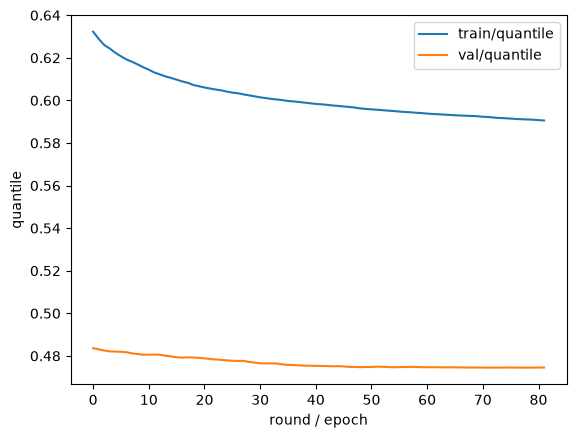

In [11]:
from matplotlib import pyplot as plt

metric = next(iter(train_history), None)
if metric is None:
    raise ValueError("train_history is empty")
plt.plot(train_history[metric], label=f"train/{metric}")
if metric in val_history:
    plt.plot(val_history[metric], label=f"val/{metric}")
plt.xlabel("round / epoch")
plt.ylabel(metric)
plt.legend()
plt.show()
